In [1]:
# %%
import numpy as np
from matplotlib import pyplot as plt
import csv

# %matplotlib inline

import xarray as xr
import lib_ecofun as lef

from scipy.optimize import curve_fit, minimize, dual_annealing, basinhopping, brute, differential_evolution, shgo, direct


In [2]:
# %%
year_ini = 2000
params = lef.default_params.copy()

verbose = False

public_investment = False

params['r_inv_state'] = 0.015
arr = np.concatenate([np.linspace(0., 0.7, 20), np.linspace(0.7, 0.7, 80)])
mu_scen = xr.DataArray(arr, dims = ('year'), coords = {'year': np.arange(year_ini, year_ini + 100)})

obs_weights = None

result_dict = {}

In [3]:
best_params = lef.best_params.copy()

In [4]:
inicond = lef.inicond_2000

In [6]:
obs = lef.define_obs(['E', 'Eg_ratio'], year_ref = year_ini)
obs_weights = {'E': 1, 'Eg_ratio': 100, 'Ig_ratio': 1}

In [ ]:
resu_best = lef.run_model(inicond = inicond, params = best_params, n_iter = 100, verbose = False, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=True)

In [8]:
result_dict['old'] = resu_best

In [23]:
from importlib import reload
reload(lef)

<module 'lib_ecofun' from '/home/fedef/Research/abstractsepapers/papers/DREAM/codes/lib_ecofun.py'>

In [11]:
cost = lef.costfun(resu_best, obs, weights = obs_weights)
print(cost)

0.08395012615024353


In [13]:
new_params = {'growth': 0.021689894906442277,
 'eps': 1,
 'a': 0.6029124381843882,
 'b': 0.579225848991004,
 'gamma_f': 0.5,
 'gamma_g': 0.5420239224016129,
 'eta_g': 0.8,
 'eta_f': 0.8,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.4618117227938998,
 'beta_0': -0.42608439969374023,
 'delta_sig': 0.9974116079168649,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [20]:
inicond_new = lef.inicond_yr(year_ini, new_params, adimensional = True, fcu = lef.fossil_capacity_util)

In [26]:
new_params

{'growth': 0.021689894906442277,
 'eps': 1,
 'a': 0.6029124381843882,
 'b': 0.579225848991004,
 'gamma_f': 0.5,
 'gamma_g': 0.5420239224016129,
 'eta_g': 0.8,
 'eta_f': 0.8,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.4618117227938998,
 'beta_0': -0.42608439969374023,
 'delta_sig': 0.9974116079168649,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [21]:
resu_new = lef.run_model(inicond = inicond_new, params = new_params, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=True)

cost = lef.costfun(resu_new, obs, weights = obs_weights)
print(cost)

params:  {'growth': 0.021689894906442277, 'eps': 1, 'a': 0.6029124381843882, 'b': 0.579225848991004, 'gamma_f': 0.5, 'gamma_g': 0.5420239224016129, 'eta_g': 0.8, 'eta_f': 0.8, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.4618117227938998, 'beta_0': -0.42608439969374023, 'delta_sig': 0.9974116079168649, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.30     -0.08      0.08      0.92      0.00      0.08      0.01      0.03
params:  {'growth': 0.021689894906442277, 'eps': 1, 'a': 0.6029124381843882, 'b': 0.579225848991004, 'gamma_f': 0.5, 'gamma_g': 0.5420239224016129, 'eta_g': 0.8, 'eta_f': 0.8, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.4618117227938998, 'beta_0': -0.42608439969374023, 'delta_sig': 0.9974116079168649, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.30     -0.11      0.08      0.94      0.00      0.08      0.01      0.03
params:  {'growth': 0.021689894906442277, 'eps': 1, 'a': 0.6029124381843882, 'b': 0.57922584

In [24]:
inicond_new2 = {'Y_ini': 1.0,
 'Eg_ini': 0.07825325742181562,
 'Ef_ini': 0.9217467425781845,
 'E_ini': 1.0,
 'Kf_ini': 2.6806534316957236,
 'Kg_ini': 0.11082089923138264}

In [31]:
new_params_orig = {'growth': 0.01,
 'eps': 1,
 'a': 0.7061236460320618,
 'b': 0.4298143932369072,
 'gamma_f': 0.5,
 'gamma_g': 0.5,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.1,
 'beta_0': 0.2,
 'delta_sig': 0.5,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [34]:
parnames = ['growth', 'delta_sig', 'beta_0', 'r_inv', 'a', 'b', 'gamma_g']

In [33]:
resu = [0.02167093528888582,
 0.504557907995271,
 -0.3903996102805064,
 0.30639145739262236,
 0.6675367164317915,
 0.744023858755827,
 0.23074172013675243]

In [32]:
new_params2 = new_params_orig.copy()

In [36]:
for par, parval in zip(parnames, resu):
    new_params2[par] = parval

In [38]:
new_params2

{'growth': 0.02167093528888582,
 'eps': 1,
 'a': 0.6675367164317915,
 'b': 0.744023858755827,
 'gamma_f': 0.5,
 'gamma_g': 0.23074172013675243,
 'eta_g': 0.2,
 'eta_f': 0.2,
 'h_g': 0.5,
 'h_f': 0.5,
 'r_inv': 0.30639145739262236,
 'beta_0': -0.3903996102805064,
 'delta_sig': 0.504557907995271,
 'delta_g': 0.01,
 'delta_f': 0.01,
 'f_heavy': 0.1,
 'r_inv_state': 0.015}

In [37]:
resu_new2 = lef.run_model(inicond = inicond_new2, params = new_params2, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=True)

cost = lef.costfun(resu_new2, obs, weights = obs_weights)
print(cost)

params:  {'growth': 0.02167093528888582, 'eps': 1, 'a': 0.6675367164317915, 'b': 0.744023858755827, 'gamma_f': 0.5, 'gamma_g': 0.23074172013675243, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.30639145739262236, 'beta_0': -0.3903996102805064, 'delta_sig': 0.504557907995271, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.03     -0.54      0.07      0.93      0.00      0.37      0.00      0.11
params:  {'growth': 0.02167093528888582, 'eps': 1, 'a': 0.6675367164317915, 'b': 0.744023858755827, 'gamma_f': 0.5, 'gamma_g': 0.23074172013675243, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.30639145739262236, 'beta_0': -0.3903996102805064, 'delta_sig': 0.504557907995271, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.03     -0.53      0.08      0.95      0.00      0.38      0.00      0.11
params:  {'growth': 0.02167093528888582, 'eps': 1, 'a': 0.6675367164317915, 'b': 0.74402385875

In [40]:
resu_new2_noscale = lef.run_model(inicond = inicond_new2, params = new_params2, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=False)

cost = lef.costfun(resu_new2_noscale, obs, weights = obs_weights)
print(cost)

params:  {'growth': 0.02167093528888582, 'eps': 1, 'a': 0.6675367164317915, 'b': 0.744023858755827, 'gamma_f': 0.5, 'gamma_g': 0.23074172013675243, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.30639145739262236, 'beta_0': -0.3903996102805064, 'delta_sig': 0.504557907995271, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.19     -0.06      0.07      0.93      0.01      0.37      0.02      0.10
params:  {'growth': 0.02167093528888582, 'eps': 1, 'a': 0.6675367164317915, 'b': 0.744023858755827, 'gamma_f': 0.5, 'gamma_g': 0.23074172013675243, 'eta_g': 0.2, 'eta_f': 0.2, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.30639145739262236, 'beta_0': -0.3903996102805064, 'delta_sig': 0.504557907995271, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.19     -0.05      0.09      0.93      0.02      0.37      0.02      0.10
params:  {'growth': 0.02167093528888582, 'eps': 1, 'a': 0.6675367164317915, 'b': 0.74402385875

In [42]:
new_params3 = new_params2.copy()
new_params3['eta_g'] = 0.8
new_params3['eta_f'] = 0.8

resu_new3_neweta = lef.run_model(inicond = inicond_new2, params = new_params3, n_iter = 100, verbose = True, rule = 'maxgreen', year_ini = year_ini, public_investment=public_investment, mu_state_scenario=mu_scen, scale_costs=False)

cost = lef.costfun(resu_new3_neweta, obs, weights = obs_weights)
print(cost)

params:  {'growth': 0.02167093528888582, 'eps': 1, 'a': 0.6675367164317915, 'b': 0.744023858755827, 'gamma_f': 0.5, 'gamma_g': 0.23074172013675243, 'eta_g': 0.8, 'eta_f': 0.8, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.30639145739262236, 'beta_0': -0.3903996102805064, 'delta_sig': 0.504557907995271, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.19     -0.06      0.07      0.93      0.00      0.09      0.01      0.02
Fossil infrastructure decreasing! 0.023902383286950716 < 0.026806534316957235
params:  {'growth': 0.02167093528888582, 'eps': 1, 'a': 0.6675367164317915, 'b': 0.744023858755827, 'gamma_f': 0.5, 'gamma_g': 0.23074172013675243, 'eta_g': 0.8, 'eta_f': 0.8, 'h_g': 0.5, 'h_f': 0.5, 'r_inv': 0.30639145739262236, 'beta_0': -0.3903996102805064, 'delta_sig': 0.504557907995271, 'delta_g': 0.01, 'delta_f': 0.01, 'f_heavy': 0.1, 'r_inv_state': 0.015}
check:       0.18     -0.07      0.08      0.94      0.00      0.09      0.01      0.02
Fossil infrastru

## CHECK

[<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>]

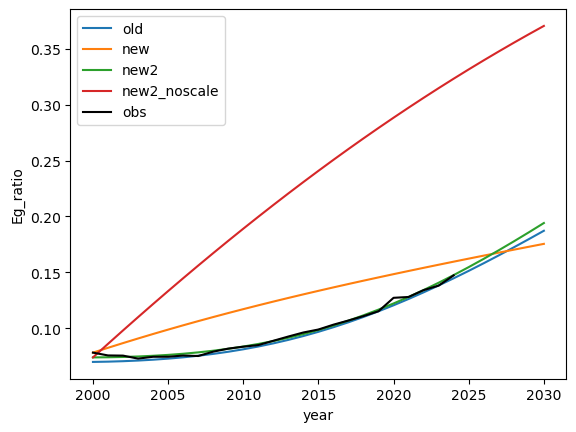

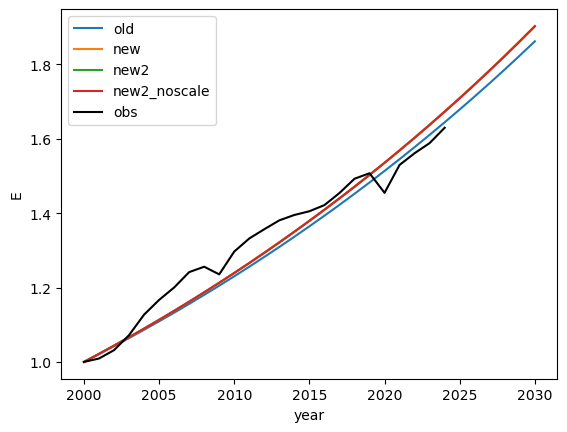

In [41]:
lef.plot_resuvsobs_ds([resu_best, resu_new, resu_new2, resu_new2_noscale], obs, run_names = ['old', 'new', 'new2', 'new2_noscale'])